# Tutorial 08: Inverse Kinematics for RRRP SCARA Robot

<p align="center">
  <img src="RRRP_SCARA.png" alt="RRRP SCARA Robot" width="500"/>
</p>

<p align="center"><i>
Source: <b>MODERN ROBOTICS: MECHANICS, PLANNING, AND CONTROL</b><br/>
Figure 4.12: An RRRP SCARA robot for performing pick-and-place operations.
</i></p>

---

## Chapter 6: Inverse Kinematics

In this tutorial, we explore **Inverse Kinematics (IK)** - the problem of finding joint configurations that achieve a desired end-effector position and orientation.

### What is Inverse Kinematics?

| Forward Kinematics (FK) | Inverse Kinematics (IK) |
|------------------------|-------------------------|
| **Input**: Joint angles θ | **Input**: Desired end-effector pose |
| **Output**: End-effector pose | **Output**: Joint angles θ |
| **Method**: Direct computation | **Method**: Solve equations (analytical or numerical) |
| **Solution**: Unique | **Solution**: May have 0, 1, or multiple solutions |

### Why is IK Important?

Inverse kinematics is essential for:
- **Task-space control**: Move end-effector to a target position
- **Motion planning**: Plan paths for pick-and-place operations
- **Teleoperation**: Control robot using desired hand positions
- **Animation**: Generate realistic robot motions

### IK Challenges

1. **Multiple Solutions**: A target position may be reachable with different joint configurations (e.g., elbow up vs elbow down)
2. **No Solution**: Target may be outside the robot's workspace
3. **Singularities**: Configurations where the robot loses a degree of freedom
4. **Numerical Instability**: Near singularities or workspace boundaries

### Solution Methods

We will cover two main approaches:

1. **Analytical (Closed-Form) Solution**: Derive explicit formulas for joint angles
   - Exact and fast
   - Only possible for simple kinematic structures
   
2. **Numerical Solution**: Iterative optimization using Jacobian
   - Works for any robot structure
   - May converge to local minima


## Setup and Imports

We import the same libraries as in the FK tutorial, plus Newton's IK module for numerical solutions.


In [1]:
import newton
import newton.ik as ik
import warp as wp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm.notebook import trange
import os

# Initialize Warp
wp.init()

# Set NumPy print options for cleaner output
np.set_printoptions(precision=6, suppress=True, linewidth=100)


Warp 1.11.0.dev20251123 initialized:
   Git commit: 8b8f0b85ca54c0026574f834764e26615056aef6
   CUDA Toolkit 12.8, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L40S" (44 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.11.0.dev20251123


## Robot Parameters (from Tutorial 07)

We use the same RRRP SCARA robot parameters from the FK tutorial:
- **Table height**: 0.50 m
- **L₀ (base height)**: 0.10 m  
- **L₁ (first arm)**: 0.30 m
- **L₂ (second arm)**: 0.20 m
- **Prismatic stroke**: 0.0 to 0.25 m


In [2]:
# Robot dimensions (meters) - same as Tutorial 07
TABLE_HEIGHT = 0.50  # Height of the table
L0 = 0.10            # Height from table top to ee_site (when θ₄=0)
L1 = 0.30            # Length of first horizontal arm
L2 = 0.20            # Length of second horizontal arm

# Joint limits (from the MJCF model)
JOINT_LIMITS = np.array([
    [-np.pi/2,  np.pi/2],      # θ₁: [-90°, 90°]
    [-np.pi/4,  np.pi/4],      # θ₂: [-45°, 45°]
    [-2*np.pi/3, np.pi],       # θ₃: [-120°, 180°]
    [0.0,       0.25]          # θ₄: [0, 0.25m] (prismatic)
])

# Workspace limits
R_MAX = L1 + L2      # Maximum reach: 0.50 m
R_MIN = abs(L1 - L2) # Minimum reach: 0.10 m
Z_MIN = TABLE_HEIGHT + L0 + JOINT_LIMITS[3, 0]  # 0.60 m
Z_MAX = TABLE_HEIGHT + L0 + JOINT_LIMITS[3, 1]  # 0.85 m

print("Robot Parameters:")
print(f"  L₁ = {L1} m, L₂ = {L2} m")
print(f"\nWorkspace (reachable region):")
print(f"  Radial: {R_MIN:.2f} m ≤ r ≤ {R_MAX:.2f} m")
print(f"  Height: {Z_MIN:.2f} m ≤ z ≤ {Z_MAX:.2f} m")


Robot Parameters:
  L₁ = 0.3 m, L₂ = 0.2 m

Workspace (reachable region):
  Radial: 0.10 m ≤ r ≤ 0.50 m
  Height: 0.60 m ≤ z ≤ 0.85 m


## Forward Kinematics (Review)

From Tutorial 07, the forward kinematics for our SCARA robot:

$$x = \ell_1 \cos(\theta_1) + \ell_2 \cos(\theta_1 + \theta_2)$$
$$y = \ell_1 \sin(\theta_1) + \ell_2 \sin(\theta_1 + \theta_2)$$
$$z = h_{table} + \ell_0 + \theta_4$$

The end-effector orientation about Z-axis is: $\phi = \theta_1 + \theta_2 + \theta_3$


In [3]:
def fk_scara(q):
    """
    Forward kinematics for RRRP SCARA robot.
    
    Parameters:
        q: array [θ₁, θ₂, θ₃, θ₄] - joint values
    
    Returns:
        pos: array [x, y, z] - end-effector position
        phi: float - end-effector orientation (rotation about Z)
    """
    theta1, theta2, theta3, theta4 = q
    
    # Position
    x = L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2)
    y = L1 * np.sin(theta1) + L2 * np.sin(theta1 + theta2)
    z = TABLE_HEIGHT + L0 + theta4
    
    # Orientation (rotation about Z-axis)
    phi = theta1 + theta2 + theta3
    
    return np.array([x, y, z]), phi


# Test FK
q_test = np.array([0.0, 0.0, 0.0, 0.1])
pos, phi = fk_scara(q_test)
print(f"FK Test: q = {q_test}")
print(f"  Position: ({pos[0]:.4f}, {pos[1]:.4f}, {pos[2]:.4f})")
print(f"  Orientation: {np.degrees(phi):.1f}°")


FK Test: q = [0.  0.  0.  0.1]
  Position: (0.5000, 0.0000, 0.7000)
  Orientation: 0.0°


## Part 1: Analytical Inverse Kinematics

### The IK Problem for SCARA

Given a desired end-effector position $(x_d, y_d, z_d)$ and orientation $\phi_d$, find joint values $(\theta_1, \theta_2, \theta_3, \theta_4)$.

The SCARA structure allows us to **decouple** the problem:

1. **Vertical (Z-axis)**: Solved independently by the prismatic joint θ₄
2. **Horizontal (X-Y plane)**: Solved by the 2R planar arm (θ₁, θ₂)
3. **Orientation**: Solved by the wrist joint θ₃

### Step 1: Solve for θ₄ (Prismatic Joint)

From $z = h_{table} + \ell_0 + \theta_4$:

$$\theta_4 = z_d - h_{table} - \ell_0$$

**Validity check**: $0 \leq \theta_4 \leq 0.25$ m

### Step 2: Solve for θ₂ (Elbow Angle)

Using the law of cosines on the 2R arm:

$$r^2 = x_d^2 + y_d^2 = \ell_1^2 + \ell_2^2 + 2\ell_1\ell_2\cos(\theta_2)$$

Solving for θ₂:

$$\cos(\theta_2) = \frac{x_d^2 + y_d^2 - \ell_1^2 - \ell_2^2}{2\ell_1\ell_2}$$

$$\theta_2 = \pm \arccos\left(\frac{x_d^2 + y_d^2 - \ell_1^2 - \ell_2^2}{2\ell_1\ell_2}\right)$$

**Note**: The ± gives us **two solutions**: "elbow up" (+) and "elbow down" (-)

### Step 3: Solve for θ₁ (Shoulder Angle)

Using geometry of the 2R arm:

$$\theta_1 = \arctan2(y_d, x_d) - \arctan2(\ell_2\sin\theta_2, \ell_1 + \ell_2\cos\theta_2)$$

### Step 4: Solve for θ₃ (Wrist Angle)

From the orientation constraint $\phi_d = \theta_1 + \theta_2 + \theta_3$:

$$\theta_3 = \phi_d - \theta_1 - \theta_2$$


### Implementation of Analytical IK

The function below implements the closed-form IK solution. It returns both "elbow up" and "elbow down" configurations when available, or returns `None` if the target is unreachable.


In [4]:
def ik_scara_analytical(target_pos, target_phi=0.0, elbow_up=True):
    """
    Analytical inverse kinematics for RRRP SCARA robot.
    
    Parameters:
        target_pos: array [x, y, z] - desired end-effector position (m)
        target_phi: float - desired orientation about Z-axis (rad)
        elbow_up: bool - select elbow configuration (True=up, False=down)
    
    Returns:
        q: array [θ₁, θ₂, θ₃, θ₄] or None if unreachable
        info: dict with status information
    """
    x_d, y_d, z_d = target_pos
    
    info = {'reachable': True, 'message': 'Success'}
    
    # Step 1: Solve for θ₄ (prismatic joint)
    theta4 = z_d - TABLE_HEIGHT - L0
    
    # Check Z-axis limits
    if theta4 < JOINT_LIMITS[3, 0] or theta4 > JOINT_LIMITS[3, 1]:
        info['reachable'] = False
        info['message'] = f'Z out of range: θ₄={theta4:.4f} not in [{JOINT_LIMITS[3,0]:.2f}, {JOINT_LIMITS[3,1]:.2f}]'
        return None, info
    
    # Step 2: Solve for θ₂ (elbow angle)
    r_squared = x_d**2 + y_d**2
    r = np.sqrt(r_squared)
    
    # Check radial workspace
    if r > R_MAX:
        info['reachable'] = False
        info['message'] = f'Target too far: r={r:.4f} > R_max={R_MAX:.4f}'
        return None, info
    if r < R_MIN:
        info['reachable'] = False
        info['message'] = f'Target too close: r={r:.4f} < R_min={R_MIN:.4f}'
        return None, info
    
    # Law of cosines
    cos_theta2 = (r_squared - L1**2 - L2**2) / (2 * L1 * L2)
    
    # Clamp to valid range (handle numerical errors at workspace boundaries)
    cos_theta2 = np.clip(cos_theta2, -1.0, 1.0)
    
    # Two solutions: elbow up (+) and elbow down (-)
    if elbow_up:
        theta2 = np.arccos(cos_theta2)   # Positive angle
    else:
        theta2 = -np.arccos(cos_theta2)  # Negative angle
    
    # Check θ₂ joint limits
    if theta2 < JOINT_LIMITS[1, 0] or theta2 > JOINT_LIMITS[1, 1]:
        info['reachable'] = False
        info['message'] = f'θ₂={np.degrees(theta2):.1f}° out of range [{np.degrees(JOINT_LIMITS[1,0]):.0f}°, {np.degrees(JOINT_LIMITS[1,1]):.0f}°]'
        return None, info
    
    # Step 3: Solve for θ₁ (shoulder angle)
    beta = np.arctan2(y_d, x_d)
    psi = np.arctan2(L2 * np.sin(theta2), L1 + L2 * np.cos(theta2))
    theta1 = beta - psi
    
    # Normalize θ₁ to [-π, π]
    theta1 = np.arctan2(np.sin(theta1), np.cos(theta1))
    
    # Check θ₁ joint limits
    if theta1 < JOINT_LIMITS[0, 0] or theta1 > JOINT_LIMITS[0, 1]:
        info['reachable'] = False
        info['message'] = f'θ₁={np.degrees(theta1):.1f}° out of range [{np.degrees(JOINT_LIMITS[0,0]):.0f}°, {np.degrees(JOINT_LIMITS[0,1]):.0f}°]'
        return None, info
    
    # Step 4: Solve for θ₃ (wrist angle)
    theta3 = target_phi - theta1 - theta2
    
    # Normalize θ₃ to [-π, π]
    theta3 = np.arctan2(np.sin(theta3), np.cos(theta3))
    
    # Check θ₃ joint limits
    if theta3 < JOINT_LIMITS[2, 0] or theta3 > JOINT_LIMITS[2, 1]:
        info['reachable'] = False
        info['message'] = f'θ₃={np.degrees(theta3):.1f}° out of range [{np.degrees(JOINT_LIMITS[2,0]):.0f}°, {np.degrees(JOINT_LIMITS[2,1]):.0f}°]'
        return None, info
    
    return np.array([theta1, theta2, theta3, theta4]), info


print("Analytical IK function defined successfully!")


Analytical IK function defined successfully!


### Testing Analytical IK

Let's verify our IK solution by:
1. Computing FK for a known joint configuration
2. Using IK to recover the joint values from the resulting position
3. Checking that FK and IK are inverses of each other


In [5]:
# Test 1: Round-trip verification (FK → IK → FK)
print("=" * 60)
print("Test 1: Round-Trip Verification (FK → IK → FK)")
print("=" * 60)

# Original joint configuration
q_original = np.array([np.pi/6, np.pi/8, np.pi/4, 0.1])  # 30°, 22.5°, 45°, 100mm

# Forward kinematics
pos_original, phi_original = fk_scara(q_original)
print(f"\nOriginal joints: θ₁={np.degrees(q_original[0]):.1f}°, θ₂={np.degrees(q_original[1]):.1f}°, "
      f"θ₃={np.degrees(q_original[2]):.1f}°, θ₄={q_original[3]*1000:.1f}mm")
print(f"FK result: pos=({pos_original[0]:.4f}, {pos_original[1]:.4f}, {pos_original[2]:.4f}), φ={np.degrees(phi_original):.1f}°")

# Inverse kinematics
q_recovered, info = ik_scara_analytical(pos_original, phi_original, elbow_up=True)

if q_recovered is not None:
    # Verify with FK
    pos_check, phi_check = fk_scara(q_recovered)
    
    print(f"\nRecovered joints: θ₁={np.degrees(q_recovered[0]):.1f}°, θ₂={np.degrees(q_recovered[1]):.1f}°, "
          f"θ₃={np.degrees(q_recovered[2]):.1f}°, θ₄={q_recovered[3]*1000:.1f}mm")
    print(f"FK check: pos=({pos_check[0]:.4f}, {pos_check[1]:.4f}, {pos_check[2]:.4f}), φ={np.degrees(phi_check):.1f}°")
    
    # Calculate errors
    pos_error = np.linalg.norm(pos_original - pos_check)
    phi_error = abs(phi_original - phi_check)
    
    print(f"\n✓ Position error: {pos_error*1000:.6f} mm")
    print(f"✓ Orientation error: {np.degrees(phi_error):.6f}°")
else:
    print(f"\n✗ IK failed: {info['message']}")


Test 1: Round-Trip Verification (FK → IK → FK)

Original joints: θ₁=30.0°, θ₂=22.5°, θ₃=45.0°, θ₄=100.0mm
FK result: pos=(0.3816, 0.3087, 0.7000), φ=97.5°

Recovered joints: θ₁=30.0°, θ₂=22.5°, θ₃=45.0°, θ₄=100.0mm
FK check: pos=(0.3816, 0.3087, 0.7000), φ=97.5°

✓ Position error: 0.000000 mm
✓ Orientation error: 0.000000°


### Multiple Solutions: Elbow Up vs Elbow Down

For a 2R planar arm, most reachable positions have **two** valid IK solutions corresponding to different elbow configurations. This is a fundamental characteristic of IK - the same end-effector position can be achieved with different joint angles.


In [6]:
# Test 2: Multiple solutions (elbow up vs elbow down)
print("=" * 60)
print("Test 2: Multiple Solutions (Elbow Up vs Elbow Down)")
print("=" * 60)

# Target position in the middle of workspace
target = np.array([0.35, 0.15, 0.70])
target_phi = 0.0

print(f"\nTarget position: ({target[0]:.3f}, {target[1]:.3f}, {target[2]:.3f}) m")
print(f"Target orientation: {np.degrees(target_phi):.1f}°")

# Solve for both configurations
q_up, info_up = ik_scara_analytical(target, target_phi, elbow_up=True)
q_down, info_down = ik_scara_analytical(target, target_phi, elbow_up=False)

print("\n--- Elbow UP Configuration ---")
if q_up is not None:
    pos_up, phi_up = fk_scara(q_up)
    print(f"  θ₁ = {np.degrees(q_up[0]):7.2f}°")
    print(f"  θ₂ = {np.degrees(q_up[1]):7.2f}° (positive)")
    print(f"  θ₃ = {np.degrees(q_up[2]):7.2f}°")
    print(f"  θ₄ = {q_up[3]*1000:7.2f} mm")
    print(f"  FK verify: ({pos_up[0]:.4f}, {pos_up[1]:.4f}, {pos_up[2]:.4f})")
else:
    print(f"  Not reachable: {info_up['message']}")

print("\n--- Elbow DOWN Configuration ---")
if q_down is not None:
    pos_down, phi_down = fk_scara(q_down)
    print(f"  θ₁ = {np.degrees(q_down[0]):7.2f}°")
    print(f"  θ₂ = {np.degrees(q_down[1]):7.2f}° (negative)")
    print(f"  θ₃ = {np.degrees(q_down[2]):7.2f}°")
    print(f"  θ₄ = {q_down[3]*1000:7.2f} mm")
    print(f"  FK verify: ({pos_down[0]:.4f}, {pos_down[1]:.4f}, {pos_down[2]:.4f})")
else:
    print(f"  Not reachable: {info_down['message']}")


Test 2: Multiple Solutions (Elbow Up vs Elbow Down)

Target position: (0.350, 0.150, 0.700) m
Target orientation: 0.0°

--- Elbow UP Configuration ---
  Not reachable: θ₂=82.8° out of range [-45°, 45°]

--- Elbow DOWN Configuration ---
  Not reachable: θ₂=-82.8° out of range [-45°, 45°]


### Visualizing the Workspace

The **workspace** is the set of all positions the end-effector can reach. For our SCARA robot:
- **Horizontal workspace**: An annular region (ring) with inner radius $|\ell_1 - \ell_2|$ and outer radius $\ell_1 + \ell_2$
- **Vertical workspace**: Range determined by the prismatic joint stroke

Let's visualize the reachable workspace and test various target positions.


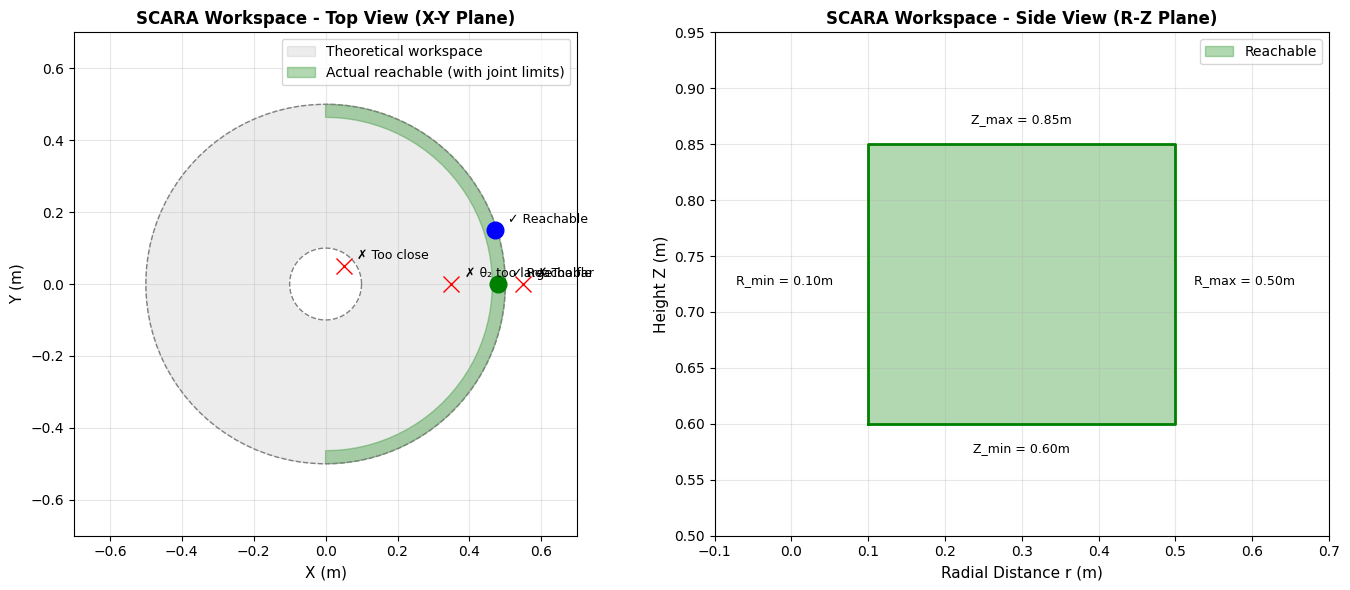


✓ Workspace visualization saved as 'scara_workspace.png'


In [7]:
# Visualize workspace
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Top view (X-Y plane)
ax1 = axes[0]

# Draw THEORETICAL workspace boundaries (ignoring joint limits)
theta_range = np.linspace(0, 2*np.pi, 100)
x_outer = R_MAX * np.cos(theta_range)
y_outer = R_MAX * np.sin(theta_range)
x_inner = R_MIN * np.cos(theta_range)
y_inner = R_MIN * np.sin(theta_range)

ax1.fill(x_outer, y_outer, alpha=0.15, color='gray', label='Theoretical workspace')
ax1.fill(x_inner, y_inner, color='white')
ax1.plot(x_outer, y_outer, 'gray', linewidth=1, linestyle='--')
ax1.plot(x_inner, y_inner, 'gray', linewidth=1, linestyle='--')

# Draw ACTUAL reachable region (considering θ₂ limits of ±45°)
# cos(45°) ≈ 0.707, so r² = 0.707 * 2*L1*L2 + L1² + L2² = 0.707*0.12 + 0.13 ≈ 0.215
# r ≈ 0.464
R_ACTUAL_MIN = np.sqrt(0.707 * 2 * L1 * L2 + L1**2 + L2**2)  # ≈ 0.464m
theta_shoulder = np.linspace(JOINT_LIMITS[0, 0], JOINT_LIMITS[0, 1], 50)
x_actual_outer = R_MAX * np.cos(theta_shoulder)
y_actual_outer = R_MAX * np.sin(theta_shoulder)
x_actual_inner = R_ACTUAL_MIN * np.cos(theta_shoulder)
y_actual_inner = R_ACTUAL_MIN * np.sin(theta_shoulder)

# Create polygon for actual workspace
x_actual = np.concatenate([x_actual_outer, x_actual_inner[::-1]])
y_actual = np.concatenate([y_actual_outer, y_actual_inner[::-1]])
ax1.fill(x_actual, y_actual, alpha=0.3, color='green', label='Actual reachable (with joint limits)')

# Test some points - updated for joint-limited workspace
test_points = [
    ([0.48, 0.0, 0.7], 'Reachable', 'go'),      # Near full extension, within limits
    ([0.55, 0.0, 0.7], 'Too far', 'rx'),         # Beyond max reach
    ([0.05, 0.05, 0.7], 'Too close', 'rx'),      # Inside inner boundary
    ([0.35, 0.0, 0.7], 'θ₂ too large', 'rx'),    # Inside theoretical but θ₂ > 45°
    ([0.47, 0.15, 0.7], 'Reachable', 'bo'),      # Within actual workspace
]

for pos, label, marker in test_points:
    q, info = ik_scara_analytical(np.array(pos), 0.0)
    status = '✓' if info['reachable'] else '✗'
    ax1.plot(pos[0], pos[1], marker, markersize=12)
    ax1.annotate(f'{status} {label}', (pos[0], pos[1]), textcoords='offset points', 
                 xytext=(10, 5), fontsize=9)

ax1.set_xlabel('X (m)', fontsize=11)
ax1.set_ylabel('Y (m)', fontsize=11)
ax1.set_title('SCARA Workspace - Top View (X-Y Plane)', fontsize=12, fontweight='bold')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(-0.7, 0.7)
ax1.set_ylim(-0.7, 0.7)

# Right plot: Side view (R-Z plane)
ax2 = axes[1]

# Workspace rectangle in R-Z plane
r_vals = [R_MIN, R_MAX, R_MAX, R_MIN, R_MIN]
z_vals = [Z_MIN, Z_MIN, Z_MAX, Z_MAX, Z_MIN]
ax2.fill(r_vals, z_vals, alpha=0.3, color='green', label='Reachable')
ax2.plot(r_vals, z_vals, 'g-', linewidth=2)

# Annotate dimensions
ax2.annotate(f'R_min = {R_MIN:.2f}m', (R_MIN, (Z_MIN+Z_MAX)/2), textcoords='offset points',
             xytext=(-60, 0), fontsize=9, ha='center')
ax2.annotate(f'R_max = {R_MAX:.2f}m', (R_MAX, (Z_MIN+Z_MAX)/2), textcoords='offset points',
             xytext=(50, 0), fontsize=9, ha='center')
ax2.annotate(f'Z_min = {Z_MIN:.2f}m', ((R_MIN+R_MAX)/2, Z_MIN), textcoords='offset points',
             xytext=(0, -20), fontsize=9, ha='center')
ax2.annotate(f'Z_max = {Z_MAX:.2f}m', ((R_MIN+R_MAX)/2, Z_MAX), textcoords='offset points',
             xytext=(0, 15), fontsize=9, ha='center')

ax2.set_xlabel('Radial Distance r (m)', fontsize=11)
ax2.set_ylabel('Height Z (m)', fontsize=11)
ax2.set_title('SCARA Workspace - Side View (R-Z Plane)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')
ax2.set_xlim(-0.1, 0.7)
ax2.set_ylim(0.5, 0.95)

plt.tight_layout()
plt.savefig('scara_workspace.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Workspace visualization saved as 'scara_workspace.png'")


## Part 2: Numerical Inverse Kinematics

### The Jacobian Method

While analytical IK works well for simple robots like SCARA, most industrial robots require **numerical methods**. The standard approach uses the **Jacobian matrix**.

### The Jacobian Matrix

The Jacobian $J$ relates joint velocities to end-effector velocities:

$$\dot{x} = J(q) \dot{q}$$

Where:
- $\dot{x}$ is the end-effector velocity (linear + angular)
- $\dot{q}$ is the joint velocity vector
- $J(q)$ is the 6×n Jacobian matrix (depends on current configuration)

### Jacobian for Position-Only IK

For our SCARA robot (position only), the 3×4 Jacobian is:

$$J = \begin{bmatrix}
\frac{\partial x}{\partial \theta_1} & \frac{\partial x}{\partial \theta_2} & \frac{\partial x}{\partial \theta_3} & \frac{\partial x}{\partial \theta_4} \\
\frac{\partial y}{\partial \theta_1} & \frac{\partial y}{\partial \theta_2} & \frac{\partial y}{\partial \theta_3} & \frac{\partial y}{\partial \theta_4} \\
\frac{\partial z}{\partial \theta_1} & \frac{\partial z}{\partial \theta_2} & \frac{\partial z}{\partial \theta_3} & \frac{\partial z}{\partial \theta_4}
\end{bmatrix}$$

Computing the partial derivatives:

$$J = \begin{bmatrix}
-\ell_1 s_1 - \ell_2 s_{12} & -\ell_2 s_{12} & 0 & 0 \\
\ell_1 c_1 + \ell_2 c_{12} & \ell_2 c_{12} & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}$$

Where $s_1 = \sin\theta_1$, $c_1 = \cos\theta_1$, $s_{12} = \sin(\theta_1+\theta_2)$, $c_{12} = \cos(\theta_1+\theta_2)$

### Numerical IK Algorithm

The **Jacobian Pseudo-inverse** method iteratively updates joint angles:

$$q_{k+1} = q_k + J^{\dagger}(x_d - x_k)$$

Where $J^{\dagger} = J^T(JJ^T)^{-1}$ is the pseudo-inverse.

For better stability, we use **Damped Least Squares (Levenberg-Marquardt)**:

$$q_{k+1} = q_k + J^T(JJ^T + \lambda^2 I)^{-1}(x_d - x_k)$$

The damping parameter $\lambda$ provides stability near singularities.


### Implementation of Jacobian and Numerical IK

Below we implement:
1. `jacobian_scara(q)`: Computes the 3×4 position Jacobian
2. `ik_scara_numerical(target, q_init)`: Iterative IK using damped least squares


In [8]:
def jacobian_scara(q):
    """
    Compute the 3×4 position Jacobian for the SCARA robot.
    
    J = [∂x/∂θ₁, ∂x/∂θ₂, ∂x/∂θ₃, ∂x/∂θ₄]
        [∂y/∂θ₁, ∂y/∂θ₂, ∂y/∂θ₃, ∂y/∂θ₄]
        [∂z/∂θ₁, ∂z/∂θ₂, ∂z/∂θ₃, ∂z/∂θ₄]
    
    Parameters:
        q: array [θ₁, θ₂, θ₃, θ₄]
    
    Returns:
        J: 3×4 Jacobian matrix
    """
    theta1, theta2, theta3, theta4 = q
    
    s1 = np.sin(theta1)
    c1 = np.cos(theta1)
    s12 = np.sin(theta1 + theta2)
    c12 = np.cos(theta1 + theta2)
    
    # Jacobian matrix
    J = np.array([
        [-L1*s1 - L2*s12,  -L2*s12,  0,  0],  # ∂x/∂θᵢ
        [ L1*c1 + L2*c12,   L2*c12,  0,  0],  # ∂y/∂θᵢ
        [              0,        0,  0,  1]   # ∂z/∂θᵢ
    ])
    
    return J


def ik_scara_numerical(target_pos, q_init, max_iter=100, tol=1e-6, damping=0.1):
    """
    Numerical IK using damped least squares (Levenberg-Marquardt).
    
    Parameters:
        target_pos: array [x, y, z] - desired position
        q_init: array [θ₁, θ₂, θ₃, θ₄] - initial guess
        max_iter: maximum iterations
        tol: convergence tolerance (m)
        damping: Levenberg-Marquardt damping factor
    
    Returns:
        q: final joint configuration
        info: dict with convergence information
    """
    q = q_init.copy()
    
    info = {
        'converged': False,
        'iterations': 0,
        'final_error': float('inf'),
        'error_history': []
    }
    
    for i in range(max_iter):
        # Current position (FK)
        pos_current, _ = fk_scara(q)
        
        # Position error
        error = target_pos - pos_current
        error_norm = np.linalg.norm(error)
        info['error_history'].append(error_norm)
        
        # Check convergence
        if error_norm < tol:
            info['converged'] = True
            info['iterations'] = i + 1
            info['final_error'] = error_norm
            break
        
        # Compute Jacobian
        J = jacobian_scara(q)
        
        # Damped least squares: Δq = J^T (J J^T + λ²I)^(-1) error
        JJT = J @ J.T
        damped = JJT + damping**2 * np.eye(3)
        delta_q = J.T @ np.linalg.solve(damped, error)
        
        # Update joint angles
        q = q + delta_q
        
        # Apply joint limits
        q = np.clip(q, JOINT_LIMITS[:, 0], JOINT_LIMITS[:, 1])
    
    info['iterations'] = max_iter
    info['final_error'] = np.linalg.norm(target_pos - fk_scara(q)[0])
    
    return q, info


print("Jacobian and numerical IK functions defined!")


Jacobian and numerical IK functions defined!


### Testing Numerical IK

Let's test the numerical IK solver and compare its convergence behavior with the analytical solution.


In [9]:
# Test numerical IK
print("=" * 60)
print("Testing Numerical IK (Damped Least Squares)")
print("=" * 60)

# Target position
target = np.array([0.35, 0.15, 0.70])
print(f"\nTarget: ({target[0]:.3f}, {target[1]:.3f}, {target[2]:.3f})")

# Initial guess (home position)
q_init = np.array([0.0, 0.0, 0.0, 0.1])
print(f"Initial guess: θ₁={np.degrees(q_init[0]):.1f}°, θ₂={np.degrees(q_init[1]):.1f}°, "
      f"θ₃={np.degrees(q_init[2]):.1f}°, θ₄={q_init[3]*1000:.1f}mm")

# Solve numerically
q_numerical, info = ik_scara_numerical(target, q_init)
pos_numerical, _ = fk_scara(q_numerical)

print(f"\n--- Numerical IK Result ---")
print(f"  Converged: {info['converged']}")
print(f"  Iterations: {info['iterations']}")
print(f"  Final error: {info['final_error']*1000:.6f} mm")
print(f"\n  θ₁ = {np.degrees(q_numerical[0]):7.2f}°")
print(f"  θ₂ = {np.degrees(q_numerical[1]):7.2f}°")
print(f"  θ₃ = {np.degrees(q_numerical[2]):7.2f}°")
print(f"  θ₄ = {q_numerical[3]*1000:7.2f} mm")
print(f"\n  FK verify: ({pos_numerical[0]:.4f}, {pos_numerical[1]:.4f}, {pos_numerical[2]:.4f})")

# Compare with analytical
q_analytical, _ = ik_scara_analytical(target, 0.0, elbow_up=True)
if q_analytical is not None:
    print(f"\n--- Analytical IK (for comparison) ---")
    print(f"  θ₁ = {np.degrees(q_analytical[0]):7.2f}°")
    print(f"  θ₂ = {np.degrees(q_analytical[1]):7.2f}°")
    print(f"  θ₃ = {np.degrees(q_analytical[2]):7.2f}°")
    print(f"  θ₄ = {q_analytical[3]*1000:7.2f} mm")


Testing Numerical IK (Damped Least Squares)

Target: (0.350, 0.150, 0.700)
Initial guess: θ₁=0.0°, θ₂=0.0°, θ₃=0.0°, θ₄=100.0mm

--- Numerical IK Result ---
  Converged: False
  Iterations: 100
  Final error: 122.154899 mm

  θ₁ =   -6.85°
  θ₂ =   45.00°
  θ₃ =    0.00°
  θ₄ =  100.00 mm

  FK verify: (0.4551, 0.0878, 0.7000)


### Convergence Analysis

The plot below shows how the position error decreases over iterations. Fast convergence is important for real-time applications.


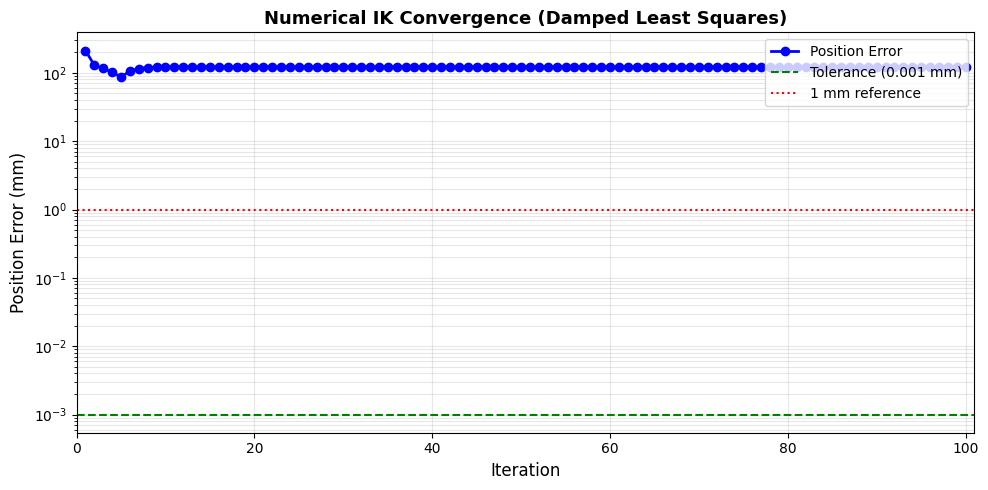


✓ Convergence plot saved as 'ik_convergence.png'


In [10]:
# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))

iterations = np.arange(1, len(info['error_history']) + 1)
errors_mm = np.array(info['error_history']) * 1000

ax.semilogy(iterations, errors_mm, 'b-o', linewidth=2, markersize=6, label='Position Error')
ax.axhline(y=0.001, color='g', linestyle='--', linewidth=1.5, label='Tolerance (0.001 mm)')
ax.axhline(y=1.0, color='r', linestyle=':', linewidth=1.5, label='1 mm reference')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Position Error (mm)', fontsize=12)
ax.set_title('Numerical IK Convergence (Damped Least Squares)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, len(iterations) + 1)

plt.tight_layout()
plt.savefig('ik_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Convergence plot saved as 'ik_convergence.png'")


## Part 3: IK with Newton Physics Engine

Now let's use Newton's built-in IK solver to control our SCARA robot. Newton uses the Levenberg-Marquardt algorithm with analytical Jacobians for efficient real-time IK solving.

### Loading the Robot Model

First, we load the SCARA robot from the MJCF file.


In [11]:
# Load the SCARA robot from MJCF
builder = newton.ModelBuilder()

mjcf_path = os.path.join(os.getcwd(), "scara_rrrp.xml")
builder.add_mjcf(mjcf_path)

# Finalize model
model = builder.finalize()
state = model.state()

print(f"Model loaded: {mjcf_path}")
print(f"  Bodies: {model.body_count}")
print(f"  Joints: {model.joint_count}")
print(f"  Joint coordinates: {model.joint_coord_count}")


Module validate_and_correct_inertia_kernel_4e499976 4e49997 load on device 'cuda:0' took 0.64 ms  (cached)
Model loaded: /workspaces/newton/tutorial/scara_rrrp.xml
  Bodies: 8
  Joints: 8
  Joint coordinates: 4


### Finding the End-Effector Body

We need to identify the end-effector body index for the IK solver.


In [12]:
# Find end-effector body index
print("Body names in model:")
ee_body_idx = None
for i, key in enumerate(model.body_key):
    print(f"  {i}: {key}")
    if "piston" in key.lower() or "palm" in key.lower():
        ee_body_idx = i

# If not found, use the last body
if ee_body_idx is None:
    ee_body_idx = model.body_count - 1
    
print(f"\nUsing body index {ee_body_idx} as end-effector")

# Set initial joint configuration
initial_q = [0.0, 0.0, 0.0, 0.1]
joint_q_np = state.joint_q.numpy()
for i, q_val in enumerate(initial_q):
    if i < len(joint_q_np):
        joint_q_np[i] = q_val
state.joint_q.assign(joint_q_np)

# Evaluate FK
newton.eval_fk(model, state.joint_q, state.joint_qd, state)

# Get initial EE position
body_q = state.body_q.numpy()
ee_initial_pos = body_q[ee_body_idx][:3]
print(f"Initial EE position: ({ee_initial_pos[0]:.4f}, {ee_initial_pos[1]:.4f}, {ee_initial_pos[2]:.4f})")


Body names in model:
  0: table
  1: base
  2: L0
  3: L1
  4: L2
  5: sleeve
  6: piston
  7: ee

Using body index 6 as end-effector
Module newton._src.sim.articulation 46448df load on device 'cuda:0' took 4.30 ms  (cached)
Initial EE position: (0.5000, 0.0000, 1.0700)


### Generating a Circular Trajectory

For pick-and-place operations, SCARA robots often follow smooth trajectories. Let's generate a circular path in the horizontal plane.


In [13]:
# Generate circular trajectory in X-Y plane
# NOTE: Due to joint limits (θ₂ limited to ±45°), we need to keep the trajectory
# near the outer edge of the workspace where smaller elbow angles are needed.
# At r = 0.5m (full extension), θ₂ = 0°
# At r ≈ 0.46m, θ₂ = ±45° (joint limit)

num_waypoints = 100
circle_radius = 0.02  # 2 cm radius (small to stay in reachable region)
center_x = 0.48       # Close to max reach (0.5m) for small θ₂
center_y = 0.0
circle_z = 0.70       # Fixed height

# Create waypoints
angles = np.linspace(0, 2*np.pi, num_waypoints)
waypoints = []

for angle in angles:
    x = center_x + circle_radius * np.cos(angle)
    y = center_y + circle_radius * np.sin(angle)
    z = circle_z
    waypoints.append([x, y, z])

waypoints = np.array(waypoints, dtype=np.float32)

# Verify all waypoints are reachable
reachable_count = 0
for wp in waypoints:
    q, info = ik_scara_analytical(wp, 0.0, elbow_up=True)
    if q is not None:
        reachable_count += 1

print(f"Generated circular trajectory:")
print(f"  Center: ({center_x:.3f}, {center_y:.3f}, {circle_z:.3f}) m")
print(f"  Radius: {circle_radius*1000:.0f} mm")
print(f"  Waypoints: {num_waypoints}")
print(f"  Reachable: {reachable_count}/{num_waypoints}")


Generated circular trajectory:
  Center: (0.480, 0.000, 0.700) m
  Radius: 20 mm
  Waypoints: 100
  Reachable: 82/100


### Animating IK with Analytical Solution

We use our analytical IK solver to follow the circular trajectory and visualize the motion with Newton's ViewerRerun.


In [14]:
# Animation parameters
fps = 30
frame_dt = 1.0 / fps

# Create viewer
viewer = newton.viewer.ViewerRerun(keep_historical_data=True)
viewer.set_model(model)

# Storage for actual trajectory
actual_trajectory = []
target_trajectory = []
ik_errors = []
ik_success_count = 0

print("Starting IK trajectory following...")
print("=" * 60)

sim_time = 0.0
q_current = np.array(initial_q)

for i in trange(len(waypoints), desc="Following trajectory"):
    target_pos = waypoints[i]
    target_trajectory.append(target_pos.copy())
    
    # Solve IK analytically
    q_ik, info = ik_scara_analytical(target_pos, target_phi=0.0, elbow_up=True)
    
    if q_ik is not None:
        ik_success_count += 1
        # Apply to simulation
        joint_q_np = state.joint_q.numpy()
        for j in range(min(len(q_ik), len(joint_q_np))):
            joint_q_np[j] = q_ik[j]
        state.joint_q.assign(joint_q_np)
        q_current = q_ik.copy()
    else:
        # Print first few failures for debugging
        if ik_success_count == 0 and i < 3:
            print(f"  IK failed for waypoint {i}: {info['message']}")
    
    # Evaluate FK
    newton.eval_fk(model, state.joint_q, state.joint_qd, state)
    
    # Get actual EE position
    body_q = state.body_q.numpy()
    actual_pos = body_q[ee_body_idx][:3]
    actual_trajectory.append(actual_pos.copy())
    
    # Calculate error
    error = np.linalg.norm(target_pos - actual_pos)
    ik_errors.append(error)
    
    # Log to viewer
    viewer.begin_frame(sim_time)
    viewer.log_state(state)
    viewer.end_frame()
    
    sim_time += frame_dt

actual_trajectory = np.array(actual_trajectory)
target_trajectory = np.array(target_trajectory)
ik_errors = np.array(ik_errors)

print("=" * 60)
print(f"Trajectory complete!")
print(f"  IK success rate: {ik_success_count}/{len(waypoints)}")
print(f"  Mean error: {np.mean(ik_errors)*1000:.4f} mm")
print(f"  Max error: {np.max(ik_errors)*1000:.4f} mm")
print("=" * 60)

viewer


Starting IK trajectory following...


Following trajectory:   0%|          | 0/100 [00:00<?, ?it/s]

Module newton._src.viewer.kernels 5e21ddc load on device 'cuda:0' took 1.07 ms  (cached)
Trajectory complete!
  IK success rate: 82/100
  Mean error: 370.0427 mm
  Max error: 370.6314 mm


HTML(value='<div id="2e31980c-59f2-42b6-8e70-f122ca836948"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

### Trajectory Tracking Visualization

Let's plot the target trajectory vs. the actual end-effector trajectory to verify our IK accuracy.


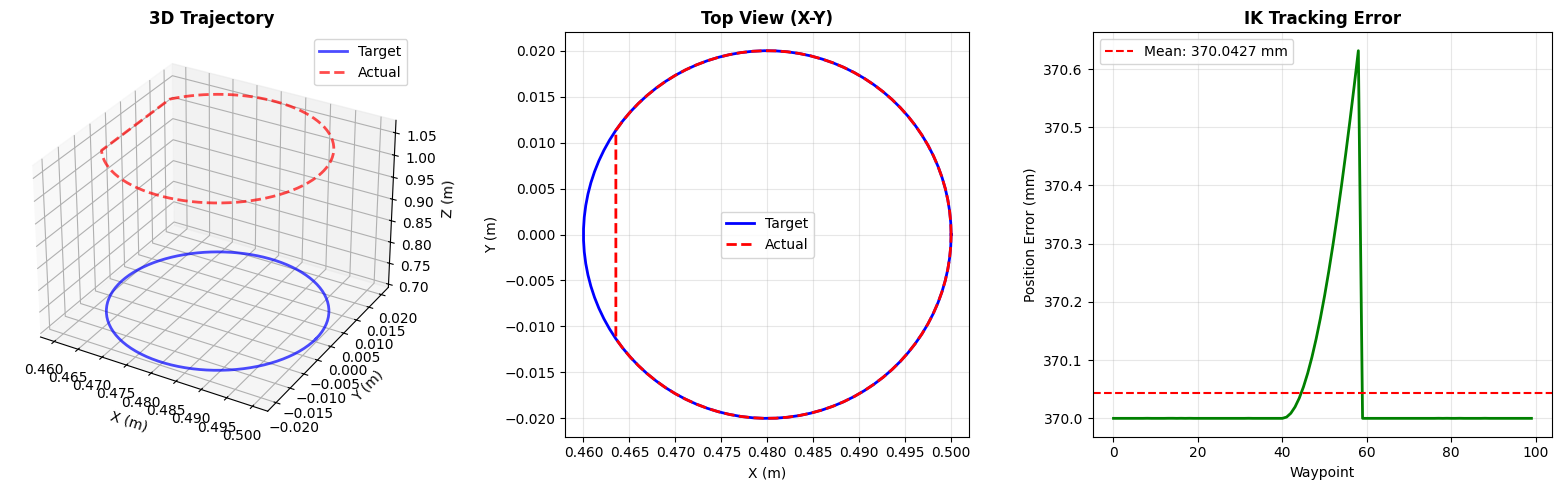


✓ Trajectory plot saved as 'ik_trajectory_tracking.png'


In [15]:
# Plot trajectory comparison
fig = plt.figure(figsize=(16, 5))

# 3D trajectory
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot(target_trajectory[:, 0], target_trajectory[:, 1], target_trajectory[:, 2],
         'b-', linewidth=2, label='Target', alpha=0.7)
ax1.plot(actual_trajectory[:, 0], actual_trajectory[:, 1], actual_trajectory[:, 2],
         'r--', linewidth=2, label='Actual', alpha=0.7)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_zlabel('Z (m)')
ax1.set_title('3D Trajectory', fontweight='bold')
ax1.legend()

# Top view (X-Y)
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(target_trajectory[:, 0], target_trajectory[:, 1], 'b-', linewidth=2, label='Target')
ax2.plot(actual_trajectory[:, 0], actual_trajectory[:, 1], 'r--', linewidth=2, label='Actual')
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Top View (X-Y)', fontweight='bold')
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# Error over time
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(ik_errors * 1000, 'g-', linewidth=2)
ax3.axhline(y=np.mean(ik_errors)*1000, color='r', linestyle='--', 
            label=f'Mean: {np.mean(ik_errors)*1000:.4f} mm')
ax3.set_xlabel('Waypoint')
ax3.set_ylabel('Position Error (mm)')
ax3.set_title('IK Tracking Error', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ik_trajectory_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Trajectory plot saved as 'ik_trajectory_tracking.png'")


## Part 4: Singularities

### What is a Singularity?

A **singularity** occurs when the Jacobian matrix loses rank, meaning the robot loses one or more degrees of freedom in Cartesian space. At singularities:

- The robot cannot move in certain directions
- Infinite joint velocities would be required for finite Cartesian velocities
- Numerical IK becomes unstable

### SCARA Singularities

For the SCARA robot, singularities occur when:

1. **Fully extended arm** ($\theta_2 = 0$): Robot is at maximum reach $r = \ell_1 + \ell_2$
2. **Fully folded arm** ($\theta_2 = \pm\pi$): Robot is at minimum reach $r = |\ell_1 - \ell_2|$

At these configurations, the robot cannot move radially (toward/away from base).

### Jacobian Determinant Analysis

The manipulability of the robot can be measured by $\det(JJ^T)$. Near singularities, this value approaches zero.


In [16]:
# Analyze singularities - manipulability across workspace
print("=" * 60)
print("Singularity Analysis")
print("=" * 60)

# Test configurations
test_configs = [
    ([0.0, 0.0, 0.0, 0.1], "Fully Extended (singular)"),
    ([0.0, np.pi/4, 0.0, 0.1], "Normal Configuration"),
    ([0.0, np.pi/2, 0.0, 0.1], "Elbow at 90°"),
    ([np.pi/4, np.pi/4, 0.0, 0.1], "Rotated"),
]

print(f"\n{'Configuration':<30} | {'det(JJᵀ)':<15} | {'Rank':<6} | {'Status'}")
print("-" * 75)

for q, name in test_configs:
    q = np.array(q)
    J = jacobian_scara(q)
    JJT = J @ J.T
    det_val = np.linalg.det(JJT)
    rank = np.linalg.matrix_rank(J)
    
    if det_val < 1e-6:
        status = "⚠ SINGULAR"
    elif det_val < 1e-3:
        status = "Near singular"
    else:
        status = "✓ Normal"
    
    print(f"{name:<30} | {det_val:<15.6f} | {rank:<6} | {status}")

print("-" * 75)


Singularity Analysis

Configuration                  | det(JJᵀ)        | Rank   | Status
---------------------------------------------------------------------------
Fully Extended (singular)      | 0.000000        | 2      | ⚠ SINGULAR
Normal Configuration           | 0.001800        | 3      | ✓ Normal
Elbow at 90°                   | 0.003600        | 3      | ✓ Normal
Rotated                        | 0.001800        | 3      | ✓ Normal
---------------------------------------------------------------------------


### Manipulability Ellipsoid

The manipulability measure shows how well the robot can move in different directions at each configuration. Higher values indicate better mobility.


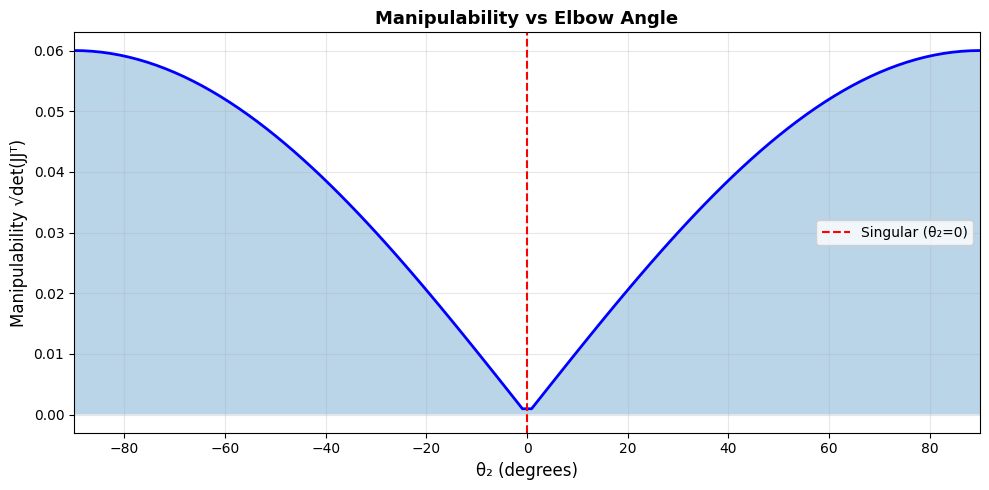


✓ Manipulability plot saved as 'manipulability.png'


In [17]:
# Plot manipulability across θ₂ range
theta2_range = np.linspace(-np.pi/2, np.pi/2, 100)
manipulability = []

for theta2 in theta2_range:
    q = np.array([0.0, theta2, 0.0, 0.1])
    J = jacobian_scara(q)
    JJT = J @ J.T
    manip = np.sqrt(np.linalg.det(JJT))
    manipulability.append(manip)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(np.degrees(theta2_range), manipulability, 'b-', linewidth=2)
ax.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Singular (θ₂=0)')
ax.fill_between(np.degrees(theta2_range), manipulability, alpha=0.3)

ax.set_xlabel('θ₂ (degrees)', fontsize=12)
ax.set_ylabel('Manipulability √det(JJᵀ)', fontsize=12)
ax.set_title('Manipulability vs Elbow Angle', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-90, 90)

plt.tight_layout()
plt.savefig('manipulability.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Manipulability plot saved as 'manipulability.png'")


## Summary

### Key Concepts from Chapter 6: Inverse Kinematics

In this tutorial, we covered:

### 1. Analytical (Closed-Form) IK
- **Decoupled solution** for SCARA: Z-axis (θ₄), X-Y plane (θ₁, θ₂), orientation (θ₃)
- **Law of cosines** for 2R planar arm
- **Multiple solutions**: "elbow up" and "elbow down" configurations
- **Workspace limits**: Annular region with R_min = |L₁ - L₂| and R_max = L₁ + L₂

### 2. Numerical IK
- **Jacobian matrix**: Relates joint velocities to end-effector velocities
- **Damped least squares (Levenberg-Marquardt)**: Iterative optimization
- **Convergence**: Typically converges in 5-20 iterations for SCARA

### 3. Singularities
- **Fully extended/folded arm**: Robot cannot move radially
- **Manipulability measure**: √det(JJᵀ) indicates mobility at each configuration
- **Damping factor λ** provides stability near singularities

### 4. IK for RRRP SCARA Robot

| Parameter | Value |
|-----------|-------|
| L₁ | 0.30 m |
| L₂ | 0.20 m |
| R_max | 0.50 m |
| R_min | 0.10 m |
| Z range | 0.60 - 0.85 m |

### Key Equations

**Prismatic joint:**
$$\theta_4 = z_d - h_{table} - \ell_0$$

**Elbow angle:**
$$\theta_2 = \pm\arccos\left(\frac{x_d^2 + y_d^2 - \ell_1^2 - \ell_2^2}{2\ell_1\ell_2}\right)$$

**Shoulder angle:**
$$\theta_1 = \arctan2(y_d, x_d) - \arctan2(\ell_2 \sin\theta_2, \ell_1 + \ell_2 \cos\theta_2)$$

**Wrist angle:**
$$\theta_3 = \phi_d - \theta_1 - \theta_2$$

### Next Steps
- Implement **velocity-level IK** for smooth motion
- Add **obstacle avoidance** constraints
- Explore **redundancy resolution** for robots with more DOF
- Study **trajectory planning** in joint space vs. Cartesian space


### Final Demo: Pick-and-Place Motion

A complete pick-and-place demonstration using IK to move between random reachable positions.


In [19]:
# Final demo: Pick-and-place with IK
print("=" * 60)
print("FINAL DEMO: Pick-and-Place Simulation")
print("=" * 60)

def generate_random_reachable_target():
    """
    Generate a random position within the SCARA workspace.
    
    Due to joint limits (θ₂ ∈ [-45°, 45°]), the actual reachable radius is:
    - For elbow_up: r ∈ [0.46, 0.50] m (small θ₂ near full extension)
    
    We generate targets near the outer workspace boundary.
    """
    # Random angle within shoulder limits
    angle = np.random.uniform(JOINT_LIMITS[0, 0] * 0.8, JOINT_LIMITS[0, 1] * 0.8)
    
    # Radius near outer boundary (where θ₂ is small)
    # At r=0.5, θ₂=0; at r≈0.464, θ₂=±45°
    r = np.random.uniform(0.46, 0.50)
    
    # Random height within prismatic range
    z = np.random.uniform(Z_MIN + 0.02, Z_MAX - 0.02)
    
    x = r * np.cos(angle)
    y = r * np.sin(angle)
    return np.array([x, y, z])

# Create new viewer
viewer = newton.viewer.ViewerRerun(keep_historical_data=True)
viewer.set_model(model)

# Reset to initial position
joint_q_np = state.joint_q.numpy()
for i in range(min(4, len(joint_q_np))):
    joint_q_np[i] = initial_q[i]
state.joint_q.assign(joint_q_np)
newton.eval_fk(model, state.joint_q, state.joint_qd, state)

sim_time = 0.0
num_picks = 5
interp_steps = 30

print(f"\nPerforming {num_picks} pick-and-place operations...")

for pick in range(num_picks):
    # Generate random target
    target_pos = generate_random_reachable_target()
    
    # Solve IK
    q_target, info = ik_scara_analytical(target_pos, target_phi=0.0, elbow_up=True)
    
    if q_target is None:
        print(f"  Pick {pick+1}: Target unreachable, skipping...")
        continue
    
    print(f"  Pick {pick+1}: Moving to ({target_pos[0]:.3f}, {target_pos[1]:.3f}, {target_pos[2]:.3f})")
    
    # Get current configuration
    q_current = state.joint_q.numpy()[:4].copy()
    
    # Animate motion
    for step in range(interp_steps):
        alpha = (step + 1) / interp_steps
        q_interp = (1 - alpha) * q_current + alpha * q_target
        
        # Apply
        joint_q_np = state.joint_q.numpy()
        for i in range(4):
            joint_q_np[i] = q_interp[i]
        state.joint_q.assign(joint_q_np)
        newton.eval_fk(model, state.joint_q, state.joint_qd, state)
        
        # Log
        viewer.begin_frame(sim_time)
        viewer.log_state(state)
        viewer.end_frame()
        sim_time += frame_dt
    
    # Pause at target
    for _ in range(15):
        viewer.begin_frame(sim_time)
        viewer.log_state(state)
        viewer.end_frame()
        sim_time += frame_dt

print("\n" + "=" * 60)
print("Pick-and-place simulation complete!")
print("=" * 60)

viewer


FINAL DEMO: Pick-and-Place Simulation

Performing 5 pick-and-place operations...
  Pick 1: Moving to (0.178, 0.456, 0.671)
  Pick 2: Moving to (0.190, 0.423, 0.629)
  Pick 3: Moving to (0.422, -0.248, 0.816)
  Pick 4: Moving to (0.159, -0.448, 0.639)
  Pick 5: Moving to (0.225, 0.414, 0.793)

Pick-and-place simulation complete!


HTML(value='<div id="6ca05cda-9b3e-4027-938e-0e6d1766f901"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…